In [ ]:
#import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist


In [2]:
#loading data
data = pd.read_csv('_358bd6a81b9045d95c894acf255c696a_nesarc_pds.csv')
print("Data loaded. Shape:", data.shape)
data.head()

Data loaded. Shape: (43093, 3008)


,ETHRACE2A,ETOTLCA2,IDNUM,PSU,STRATUM,WEIGHT,CDAY,CMON,CYEAR,REGION,...,SOL12ABDEP,SOLP12ABDEP,HAL12ABDEP,HALP12ABDEP,MAR12ABDEP,MARP12ABDEP,HER12ABDEP,HERP12ABDEP,OTHB12ABDEP,OTHBP12ABDEP
0,5,,1,4007,403,3928.613505,14,8,2001,4,...,0,0,0,0,0,0,0,0,0,0
1,5,0.0014,2,6045,604,3638.691845,12,1,2002,4,...,0,0,0,0,0,0,0,0,0,0
2,5,,3,12042,1218,5779.032025,23,11,2001,3,...,0,0,0,0,0,0,0,0,0,0
3,5,,4,17099,1704,1071.754303,9,9,2001,2,...,0,0,0,0,0,0,0,0,0,0
4,2,,5,17099,1704,4986.952377,18,10,2001,2,...,0,0,0,0,0,0,0,0,0,0


In [3]:
#data management 
data.columns = map(str.upper, data.columns)

#droping missing rows
cluster_vars = ['AGE', 'SEX', 'REGION', 'MARITAL']
data_clean = data[cluster_vars].dropna()

data_clean['SEX'] = data_clean['SEX'].replace({2: 0})  
data_clean['REGION'] = preprocessing.LabelEncoder().fit_transform(data_clean['REGION'])
data_clean['MARITAL'] = preprocessing.LabelEncoder().fit_transform(data_clean['MARITAL'])
data_clean.head()


,AGE,SEX,REGION,MARITAL
0,23,1,3,5
1,28,0,3,0
2,81,0,2,2
3,18,1,1,5
4,36,1,1,0


In [4]:
#standardization of data
clustervar = data_clean.copy()
for col in clustervar.columns:
    clustervar[col] = preprocessing.scale(clustervar[col].astype('float64'))

In [5]:
clus_train = clustervar

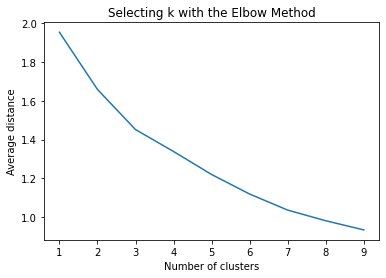

In [6]:
clusters = range(1, 10)
meandist = []
for k in clusters:
    model = KMeans(n_clusters=k, random_state=1301)
    model.fit(clus_train)
    meandist.append(sum(np.min(cdist(clus_train, model.cluster_centers_, 'euclidean'), axis=1)) / clus_train.shape[0])
plt.plot(clusters, meandist)
plt.xlabel('Number of clusters')
plt.ylabel('Average distance')
plt.title('Selecting k with the Elbow Method')
plt.show()


In [7]:
#running cluster with chosen number
k_opt = 3  
model = KMeans(n_clusters=k_opt, random_state=1301)
model.fit(clus_train)
clus_assign = model.predict(clus_train)


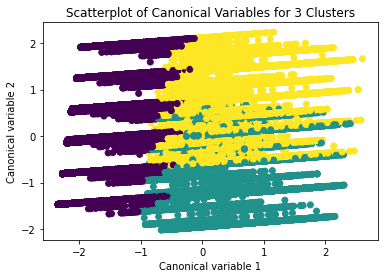

In [8]:
#visualisation of cluster
pca_2 = PCA(2)
plot_columns = pca_2.fit_transform(clus_train)
plt.scatter(x=plot_columns[:, 0], y=plot_columns[:, 1], c=model.labels_)
plt.xlabel('Canonical variable 1')
plt.ylabel('Canonical variable 2')
plt.title(f'Scatterplot of Canonical Variables for {k_opt} Clusters')
plt.show()

In [9]:
#cluster characteristics analyse
clus_train_df = clus_train.copy()
clus_train_df['cluster'] = model.labels_
print(clus_train_df['cluster'].value_counts())  # Cluster frequencies

clustergrp = clus_train_df.groupby('cluster').mean()
print("Clustering variable means by cluster")
print(clustergrp)

2    18379
1    13369
0    11345
Name: cluster, dtype: int64
Clustering variable means by cluster
              AGE       SEX    REGION   MARITAL
cluster                                        
0       -0.823604  0.048753 -0.018973  1.393292
1        0.254386  1.151993  0.011095 -0.580151
2        0.323353 -0.868061  0.003642 -0.438047


We can see that when we chosen range for the cluster from 1-10 elbow can be clearly seen at k=3 which we considered further for running cluster on single chosen point.